<a href="https://colab.research.google.com/github/Apyhtml20/Abades-SLM/blob/main/DDPM_COMPLETE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DDPM — Denoising Diffusion Probabilistic Models
Implémentation complète from scratch sur FashionMNIST.

**Architecture :** UNet avec Time Embedding (sinusoïdal), ResBlocks (GroupNorm), Self-Attention au bottleneck.

**Pipeline :**
1. Forward diffusion (ajout de bruit progressif)
2. Entraînement du UNet à prédire le bruit
3. Sampling (débruitage itératif)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
# ── Hyperparamètres ──────────────────────────────────────────────
T            = 1000        # nombre de pas de diffusion
img_size     = 28
batch_size   = 128
epochs       = 20
lr           = 1e-3
base_channels = 64         # canaux de base du UNet
time_dim     = 256         # dimension du time embedding

In [4]:
# ── Dataset FashionMNIST ─────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)   # [0,1] → [-1,1]
])

train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True
)
print(f'Taille dataset : {len(train_dataset)} images')

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.5MB/s]

Taille dataset : 60000 images


## 1. Paramètres de diffusion (schedule linéaire)

In [5]:
# ── Schedule linéaire β ──────────────────────────────────────────
beta      = torch.linspace(1e-4, 0.02, T).to(device)   # β_1 … β_T
alpha     = 1.0 - beta                                  # α_t
alpha_bar = torch.cumprod(alpha, dim=0)                 # ᾱ_t = ∏ αₛ

# Quantités utiles pour le sampling
sqrt_alpha_bar     = torch.sqrt(alpha_bar)
sqrt_one_minus_ab  = torch.sqrt(1.0 - alpha_bar)
sqrt_recip_alpha   = torch.sqrt(1.0 / alpha)
alpha_bar_prev     = torch.cat([torch.tensor([1.0], device=device), alpha_bar[:-1]])
posterior_variance = beta * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)

def extract(a, t, x_shape):
    """Extrait les valeurs a[t] et les redimensionne pour le broadcasting."""
    b = t.shape[0]
    out = a[t]
    return out.reshape(b, *([1] * (len(x_shape) - 1)))

print('Schedule OK — ᾱ_T =', alpha_bar[-1].item())

Schedule OK — ᾱ_T = 4.035829260828905e-05


## 2. Forward diffusion  q(xₜ | x₀)

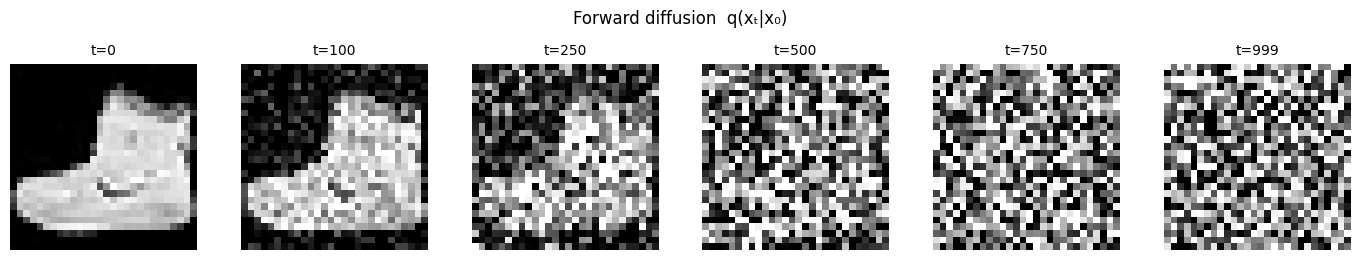

In [6]:
def q_sample(x0, t, noise=None):
    """
    Ajoute du bruit à x0 au pas t.
    xₜ = √ᾱₜ · x₀ + √(1−ᾱₜ) · ε,  ε ~ N(0,I)
    """
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab  = extract(sqrt_alpha_bar,    t, x0.shape)
    sqrt_omab = extract(sqrt_one_minus_ab, t, x0.shape)
    return sqrt_ab * x0 + sqrt_omab * noise, noise


# ── Visualisation du forward process ────────────────────────────
sample_img, _ = train_dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)

fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
timesteps_viz = [0, 100, 250, 500, 750, 999]
for ax, step in zip(axes, timesteps_viz):
    t_viz = torch.tensor([step], device=device)
    noisy, _ = q_sample(sample_img, t_viz)
    img_np = noisy[0, 0].cpu().clamp(-1, 1).numpy()
    ax.imshow(img_np, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f't={step}', fontsize=10)
    ax.axis('off')
plt.suptitle('Forward diffusion  q(xₜ|x₀)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 3. Architecture UNet

In [7]:
# ── 3.1 Time Embedding sinusoïdal ────────────────────────────────
class TimeEmbedding(nn.Module):
    """
    Transforme un entier t en vecteur de dimension d_model
    via encodage positionnel sinusoïdal (comme dans Transformers),
    suivi de deux couches linéaires + SiLU.
    """
    def __init__(self, d_model=128):
        super().__init__()
        self.d_model = d_model
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.SiLU(),
            nn.Linear(d_model * 4, d_model),
        )

    def forward(self, t):
        # t : (B,)  entiers
        half = self.d_model // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32, device=t.device) / (half - 1)
        )                                            # (half,)
        args  = t[:, None].float() * freqs[None, :] # (B, half)
        emb   = torch.cat([torch.sin(args), torch.cos(args)], dim=1)  # (B, d_model)
        return self.mlp(emb)                         # (B, d_model)

In [8]:
# ── 3.2 Residual Block ───────────────────────────────────────────
class ResBlock(nn.Module):
    """
    Bloc résiduel avec injection du time embedding.
    GroupNorm + Conv2d × 2  +  projection temporelle.
    """
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1    = nn.GroupNorm(8, in_ch)
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.norm2    = nn.GroupNorm(8, out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch)  # injecte t
        self.skip     = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act      = nn.SiLU()

    def forward(self, x, t_emb):
        # x     : (B, in_ch, H, W)
        # t_emb : (B, time_dim)
        h = self.conv1(self.act(self.norm1(x)))
        h = h + self.time_proj(self.act(t_emb))[:, :, None, None]  # injection
        h = self.conv2(self.act(self.norm2(h)))
        return h + self.skip(x)                      # connexion résiduelle

In [9]:
# ── 3.3 Self-Attention Block ─────────────────────────────────────
class AttentionBlock(nn.Module):
    """
    Self-Attention 2D (multi-head) appliqué pixel par pixel.
    Utilisé au bottleneck du UNet pour capturer les dépendances globales.
    """
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm  = nn.GroupNorm(8, channels)
        self.attn  = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        h = h.reshape(B, C, H * W).permute(0, 2, 1)  # (B, HW, C)
        h, _ = self.attn(h, h, h)
        h = h.permute(0, 2, 1).reshape(B, C, H, W)   # (B, C, H, W)
        return x + h                                   # résiduel

In [10]:
# ── 3.4 UNet DDPM ────────────────────────────────────────────────
class UNet(nn.Module):
    """
    UNet conditionné sur le pas de temps t.
    Encoder : 3 niveaux de résolution avec downsampling.
    Bottleneck : ResBlock + Attention + ResBlock.
    Decoder : 3 niveaux avec skip-connections et upsampling.
    """
    def __init__(self, in_channels=1, base_channels=64, time_dim=256):
        super().__init__()
        C = base_channels
        self.time_emb = TimeEmbedding(d_model=time_dim)

        # ── Encoder ───────────────────────────────────────────────
        self.init_conv = nn.Conv2d(in_channels, C, 3, padding=1)  # 28×28

        self.enc1 = ResBlock(C,     C,     time_dim)   # 28×28
        self.down1 = nn.Conv2d(C,   C,     3, stride=2, padding=1)  # → 14×14

        self.enc2 = ResBlock(C,     C*2,   time_dim)   # 14×14
        self.down2 = nn.Conv2d(C*2, C*2,   3, stride=2, padding=1)  # → 7×7

        self.enc3 = ResBlock(C*2,   C*4,   time_dim)   # 7×7
        self.down3 = nn.Conv2d(C*4, C*4,   3, stride=2, padding=1)  # → 4×4 (pad)

        # ── Bottleneck ────────────────────────────────────────────
        self.mid1  = ResBlock(C*4,  C*4,   time_dim)
        self.attn  = AttentionBlock(C*4)
        self.mid2  = ResBlock(C*4,  C*4,   time_dim)

        # ── Decoder ───────────────────────────────────────────────
        self.up3   = nn.ConvTranspose2d(C*4, C*4, 4, stride=2, padding=1)  # → 7×7
        self.dec3  = ResBlock(C*4 + C*4, C*2, time_dim)  # skip enc3

        self.up2   = nn.ConvTranspose2d(C*2, C*2, 4, stride=2, padding=1)  # → 14×14
        self.dec2  = ResBlock(C*2 + C*2, C,   time_dim)  # skip enc2

        self.up1   = nn.ConvTranspose2d(C,   C,   4, stride=2, padding=1)  # → 28×28
        self.dec1  = ResBlock(C   + C,   C,   time_dim)  # skip enc1

        # ── Sortie ────────────────────────────────────────────────
        self.out_norm = nn.GroupNorm(8, C)
        self.out_conv = nn.Conv2d(C, in_channels, 1)

    def forward(self, x, t):
        # x : (B, 1, 28, 28)   t : (B,)
        t_emb = self.time_emb(t)                   # (B, time_dim)

        # Encoder
        x0 = self.init_conv(x)                     # (B, C, 28, 28)
        s1 = self.enc1(x0, t_emb)                  # skip 28×28
        x1 = self.down1(s1)                        # (B, C, 14, 14)

        s2 = self.enc2(x1, t_emb)                  # skip 14×14
        x2 = self.down2(s2)                        # (B, 2C, 7×7)

        s3 = self.enc3(x2, t_emb)                  # skip 7×7
        x3 = self.down3(s3)                        # (B, 4C, 4×4)

        # Bottleneck
        x3 = self.mid1(x3, t_emb)
        x3 = self.attn(x3)
        x3 = self.mid2(x3, t_emb)

        # Decoder (avec skip)
        x3 = self.up3(x3)
        # Ajustement de taille si nécessaire (bords impairs)
        x3 = torch.nn.functional.interpolate(x3, size=s3.shape[2:], mode='nearest')
        x3 = self.dec3(torch.cat([x3, s3], dim=1), t_emb)

        x2 = self.up2(x3)
        x2 = torch.nn.functional.interpolate(x2, size=s2.shape[2:], mode='nearest')
        x2 = self.dec2(torch.cat([x2, s2], dim=1), t_emb)

        x1 = self.up1(x2)
        x1 = torch.nn.functional.interpolate(x1, size=s1.shape[2:], mode='nearest')
        x1 = self.dec1(torch.cat([x1, s1], dim=1), t_emb)

        # Sortie
        return self.out_conv(torch.nn.functional.silu(self.out_norm(x1)))


# ── Test rapide de l'architecture ───────────────────────────────
model = UNet(in_channels=1, base_channels=base_channels, time_dim=time_dim).to(device)
x_test = torch.randn(2, 1, 28, 28).to(device)
t_test = torch.randint(0, T, (2,)).to(device)
out    = model(x_test, t_test)
print(f'Output shape : {out.shape}  ✓')
n_params = sum(p.numel() for p in model.parameters())
print(f'Nb paramètres : {n_params:,}')

Output shape : torch.Size([2, 1, 28, 28])  ✓
Nb paramètres : 7,964,929


## 4. Entraînement

Epoch  1/20  |  Loss : 0.0515
Epoch  2/20  |  Loss : 0.0436
Epoch  3/20  |  Loss : 0.0420
Epoch  4/20  |  Loss : 0.0405
Epoch  5/20  |  Loss : 0.0393
Epoch  6/20  |  Loss : 0.0394
Epoch  7/20  |  Loss : 0.0389
Epoch  8/20  |  Loss : 0.0382
Epoch  9/20  |  Loss : 0.0378
Epoch 10/20  |  Loss : 0.0375
Epoch 11/20  |  Loss : 0.0373
Epoch 12/20  |  Loss : 0.0365
Epoch 13/20  |  Loss : 0.0365
Epoch 14/20  |  Loss : 0.0363
Epoch 15/20  |  Loss : 0.0358
Epoch 16/20  |  Loss : 0.0358
Epoch 17/20  |  Loss : 0.0353
Epoch 18/20  |  Loss : 0.0350
Epoch 19/20  |  Loss : 0.0352
Epoch 20/20  |  Loss : 0.0348


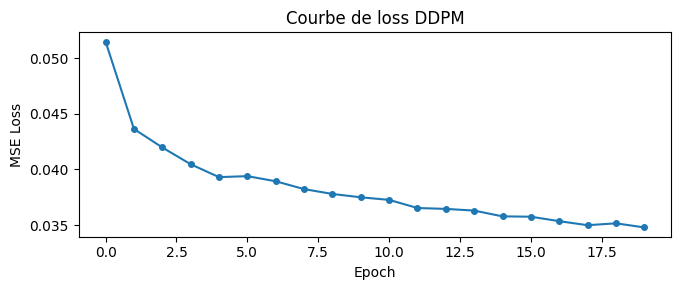

In [12]:
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
loss_fn   = nn.MSELoss()

train_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0

    for x0, _ in train_loader:
        x0 = x0.to(device)                             # (B, 1, 28, 28)
        B  = x0.shape[0]

        # 1. Tirage aléatoire du pas de temps
        t = torch.randint(0, T, (B,), device=device)   # (B,)

        # 2. Forward diffusion
        xt, noise = q_sample(x0, t)                    # bruit réel ε

        # 3. Prédiction du bruit par le UNet
        noise_pred = model(xt, t)

        # 4. Loss MSE entre ε prédit et ε réel
        loss = loss_fn(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # stabilité
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg = epoch_loss / len(train_loader)
    train_losses.append(avg)
    print(f'Epoch {epoch:>2}/{epochs}  |  Loss : {avg:.4f}')

# Courbe de loss
plt.figure(figsize=(7, 3))
plt.plot(train_losses, marker='o', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Courbe de loss DDPM')
plt.tight_layout()
plt.show()

## 5. Sampling (reverse diffusion)  p(xₜ₋₁ | xₜ)

In [13]:
@torch.no_grad()
def p_sample(model, xt, t_idx):
    """
    Un pas de débruitage DDPM :
    x_{t-1} = 1/√αₜ · (xₜ − β̃ₜ/√(1−ᾱₜ) · εθ(xₜ,t))  +  σₜ · z
    """
    B = xt.shape[0]
    t_tensor = torch.full((B,), t_idx, device=device, dtype=torch.long)

    # Prédiction du bruit
    eps_pred = model(xt, t_tensor)

    # Extraire les scalaires
    b_t      = extract(beta,             t_tensor, xt.shape)
    sqrt_omab = extract(sqrt_one_minus_ab, t_tensor, xt.shape)
    sqrt_ra   = extract(sqrt_recip_alpha,  t_tensor, xt.shape)

    # Moyenne de la distribution postérieure
    mean = sqrt_ra * (xt - b_t / sqrt_omab * eps_pred)

    if t_idx == 0:
        return mean

    # Variance postérieure
    var = extract(posterior_variance, t_tensor, xt.shape)
    z   = torch.randn_like(xt)
    return mean + torch.sqrt(var) * z


@torch.no_grad()
def generate(model, n_samples=16, show_steps=False):
    """Génère n_samples images en débruitant depuis du bruit pur."""
    model.eval()
    x = torch.randn(n_samples, 1, img_size, img_size, device=device)

    for t_idx in reversed(range(T)):
        x = p_sample(model, x, t_idx)

        # Visualisation intermédiaire (optionnel)
        if show_steps and t_idx in [750, 500, 250, 100, 0]:
            fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.5, 1.8))
            for ax, img in zip(axes, x):
                ax.imshow(img[0].cpu().clamp(-1,1).numpy(), cmap='gray', vmin=-1, vmax=1)
                ax.axis('off')
            plt.suptitle(f't={t_idx}', fontsize=10)
            plt.show()

    return x


print('Fonction de sampling prête.')

Fonction de sampling prête.


Génération en cours (peut prendre 1–2 min sur GPU)...


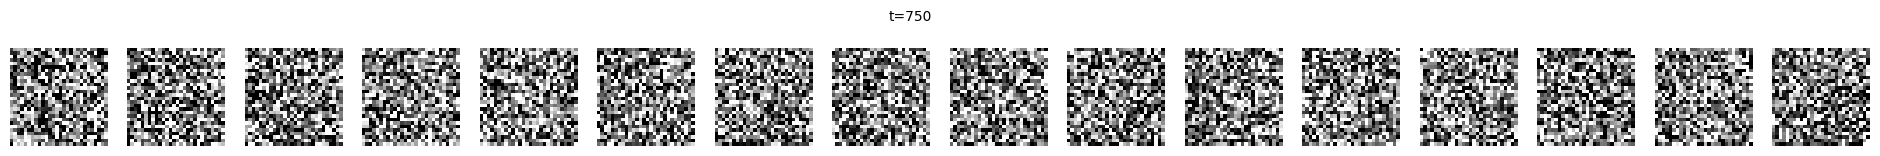

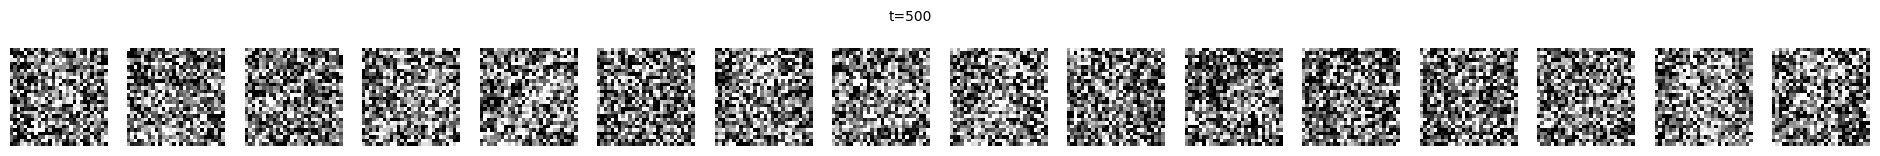

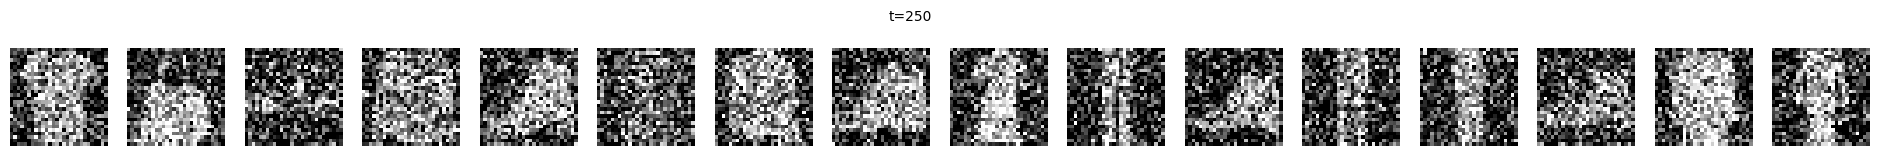

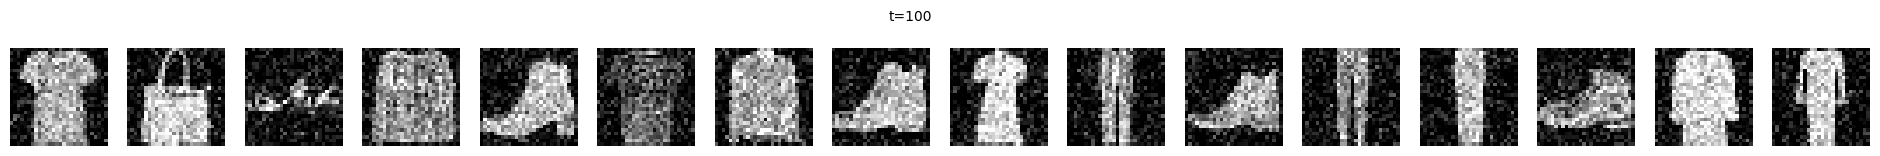

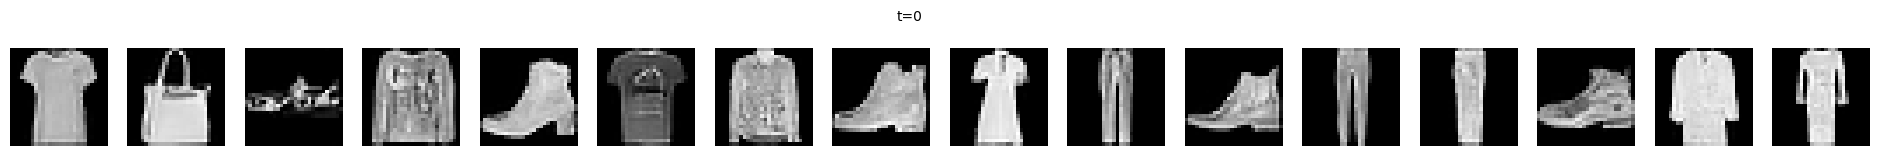

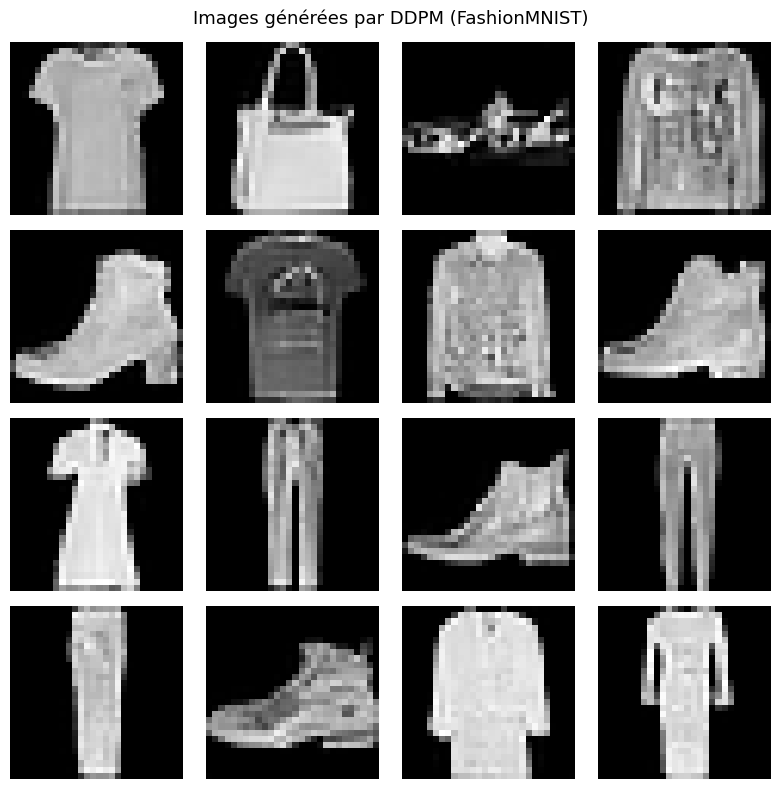

In [14]:
# ── Génération ───────────────────────────────────────────────────
print('Génération en cours (peut prendre 1–2 min sur GPU)...')
generated = generate(model, n_samples=16, show_steps=True)

# Affichage final
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, img in zip(axes.flatten(), generated):
    ax.imshow(img[0].cpu().clamp(-1,1).numpy(), cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')
plt.suptitle('Images générées par DDPM (FashionMNIST)', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# ── Sauvegarde du modèle ─────────────────────────────────────────
torch.save(model.state_dict(), 'ddpm_fashionmnist.pth')
print('Modèle sauvegardé : ddpm_fashionmnist.pth')

Modèle sauvegardé : ddpm_fashionmnist.pth
